In [1]:
import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt
import ipywidgets as widgets

plt.style.use("default")

In [2]:
def show_pdf(pdf, xmin, xmax, grid_size, distr_name, **kwargs):
    X = np.linspace(xmin, xmax, grid_size)
    Y = pdf(X, **kwargs)
    
    ymax = max(Y) + 0.1
    plt.figure(figsize=(6, 3))
    plt.plot(X, Y, lw=5)
    plt.grid(ls=':')
    plt.xlabel('Значение', fontsize=10)
    plt.ylabel('Плотность', fontsize=10)
    plt.xlim((xmin, xmax))
    plt.ylim((-0.05, ymax))
    title = 'Плотность {}'. format(distr_name)
    plt.title(title.format(**kwargs), fontsize=14)
    plt.show()

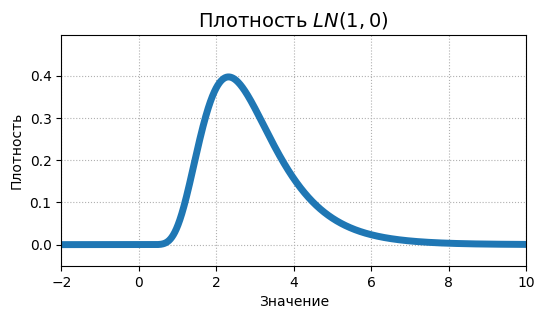

In [3]:
show_pdf(
    pdf=sts.lognorm.pdf, xmin=-2, xmax=10, grid_size=10000,
    distr_name=r'$LN(1, 0)$', s=0.4, scale=np.exp(1)
)

## Исследование зависимости плотности

In [39]:
# создаём интерактивный виджет, но не отображаем автоматически
ip = widgets.interactive(
    show_pdf,
    pdf = widgets.fixed(sts.lognorm.pdf),
    grid_size = widgets.IntSlider(
        min=100, max=5000, step=100, value=1000,
        description=r'$grid\_size$'
    ),
    xmin = widgets.FloatSlider(
        min=-2, max=0, step=0.1, value=-2,
        description=r'$x_{min}=$'
    ),
    xmax = widgets.FloatSlider(
        min=2, max=10, step=0.1, value=10,
        description=r'$x_{max}=$'
    ),
    # параметры логнормального распределения
    s = widgets.FloatSlider(
        min=0.1, max=2, step=0.1, value=0.4,
        description=r'$σ=$'
    ),
    scale = widgets.FloatSlider(
        min=0.5, max=5, step=0.1, value=np.exp(1),
        description=r'$a=$'
    ),
    distr_name = r'$LN(a={scale:.2f}, σ={s:.2f})$'
)

# отображаем слайдеры группами 
display(widgets.VBox(ip.children[:2] + ip.children[4:]))

# запустить отрисовку до первого движения слайдера
ip.update()

In [63]:
def plot_lognorm(a=0, sigma=1, n_points=10_000):
    plt.figure(figsize=(6, 3))
    sample = sts.lognorm.rvs(s=sigma, scale=np.exp(a), size=n_points)  
    
    plt.hist(sample, bins=30, density=True, alpha=0.6, label='Гистограмма выборки')
    grid = np.linspace(0.01, np.exp(a + 3*sigma), n_points)
    plt.plot(grid, sts.lognorm.pdf(grid, s=sigma, scale=np.exp(a)), color='red', lw=3, label='Плотность случайной величины')
    plt.title(r'Логнормальная величина $X \sim LN(a,\sigma)$', fontsize=10)
    plt.legend(fontsize=8, loc=8) 
    plt.grid(ls=':')
    plt.show()
    
    # Аналитические формулы для ЛОГНОРМАЛЬНОГО распределения
    mu_analytical = np.exp(a + (sigma**2)/2)           # Математическое ожидание
    var_analytical = np.exp(2*a + sigma**2) * (np.exp(sigma**2) - 1)  # Дисперсия
    
    print(f'Математическое ожидание: {round(sample.mean(), 3)}, а по формуле: {round(mu_analytical, 3)}')
    print(f'Дисперсия: {round(sample.var(), 3)}, а по формуле: {round(var_analytical, 3)}')

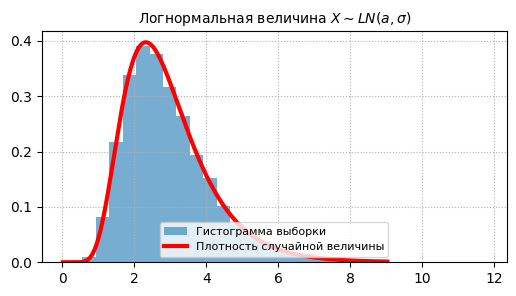

Математическое ожидание: 2.94, а по формуле: 2.945
Дисперсия: 1.512, а по формуле: 1.505


In [65]:
plot_lognorm(1, 0.4)